In [1]:
import os
import pandas as pd
import numpy as np

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

In [2]:
raw_path = "../data/raw/"
df = pd.read_csv(os.path.join(raw_path, "clean2.data"), header=None)

n_cols = df.shape[1]
columns = ["ID"] + [f"attr_{i}" for i in range(1, n_cols)]
df.columns = columns
df.head()

,ID,attr_1,attr_2,attr_3,attr_4,attr_5,attr_6,attr_7,attr_8,attr_9,...,attr_159,attr_160,attr_161,attr_162,attr_163,attr_164,attr_165,attr_166,attr_167,attr_168
0,MUSK-211,211_1+1,46,-108,-60,-69,-117,49,38,-161,...,-308,52,-7,39,126,156,-50,-112,96,1.0
1,MUSK-211,211_1+10,41,-188,-145,22,-117,-6,57,-171,...,-59,-2,52,103,136,169,-61,-136,79,1.0
2,MUSK-211,211_1+11,46,-194,-145,28,-117,73,57,-168,...,-134,-154,57,143,142,165,-67,-145,39,1.0
3,MUSK-211,211_1+12,41,-188,-145,22,-117,-7,57,-170,...,-60,-4,52,104,136,168,-60,-135,80,1.0
4,MUSK-211,211_1+13,41,-188,-145,22,-117,-7,57,-170,...,-60,-4,52,104,137,168,-60,-135,80,1.0


In [3]:
numeric_df = df.select_dtypes(include=np.number)
X_numeric = numeric_df.values

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_numeric)

In [4]:
df['target'] = df['ID'].apply(lambda x: 1 if x.startswith('MUSK') else 0)

In [5]:
n_components = 40
pca = PCA(n_components=n_components)
X_pca = pca.fit_transform(X_scaled)

In [6]:
print(pca.explained_variance_ratio_.sum())

0.9525215745431159


In [7]:
pca_names = [f'PC{i+1}' for i in range(X_pca.shape[1])]
df_X_pca = pd.DataFrame(X_pca, columns=pca_names)
df_X_pca

,PC1,PC2,PC3,PC4,PC5,PC6,PC7,PC8,PC9,PC10,...,PC31,PC32,PC33,PC34,PC35,PC36,PC37,PC38,PC39,PC40
0,-1.189404,-9.518828,2.026462,1.062459,-0.716024,-0.618485,2.957323,-0.353045,1.078284,0.341688,...,0.708460,-0.038352,-0.429691,-0.274577,-0.281189,0.269855,-0.193454,-0.114124,0.474642,0.115779
1,3.309389,-8.227524,0.973563,-1.341786,-1.438254,-2.367162,0.856111,0.401112,-2.970039,-0.826045,...,0.051086,0.382608,0.109723,0.723473,-0.576852,0.220097,0.609762,-0.624807,-0.528921,-0.636092
2,3.431082,-7.864557,-1.780094,-1.050933,-0.234928,-1.124603,0.481980,0.360528,-3.323243,-1.118161,...,-0.096960,0.453461,0.660108,0.644858,-1.012001,0.056211,0.501112,0.073313,-0.096707,0.324194
3,3.313595,-8.255922,0.949925,-1.311532,-1.428637,-2.338576,0.880408,0.398761,-2.960235,-0.810717,...,0.050646,0.385752,0.132939,0.711574,-0.571175,0.218874,0.599920,-0.614869,-0.526679,-0.638498
4,3.311826,-8.257572,0.947638,-1.310527,-1.423629,-2.337515,0.883856,0.394768,-2.958902,-0.806154,...,0.049892,0.388197,0.132449,0.712368,-0.568733,0.219897,0.597598,-0.613389,-0.526095,-0.638494
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
6593,-9.494048,0.898167,1.949929,-3.673861,-1.180910,0.452474,-2.079702,1.612522,-1.507907,1.524703,...,-0.721890,-0.364302,0.343927,0.376129,-0.215489,0.332761,-0.308791,0.317861,-0.626487,-0.241682
6594,-9.375673,1.688995,-4.110545,-2.627790,0.300338,-0.777087,-1.723719,0.739943,-1.968718,0.198267,...,-0.710665,-0.296546,0.732371,0.123762,0.093985,0.314853,-0.054595,0.130022,-0.661456,-0.200773
6595,-9.379095,1.366848,-3.834465,-3.015906,0.935915,-0.457423,-1.063717,-0.032504,-1.582986,-0.885375,...,-0.346900,-1.203430,-0.152575,-0.766622,0.779719,0.445467,-0.153859,-0.753538,-0.614847,-0.759140
6596,-9.443689,0.639067,2.247665,-4.045672,-0.526319,0.799622,-1.590095,0.947675,-1.298830,0.398599,...,-0.357156,-1.321031,-0.573055,-0.612959,0.610371,0.454020,-0.372784,-0.693273,-0.638686,-0.846968


In [8]:
df_X_pca['target'] = df['target'].values
df_X_pca.head()

,PC1,PC2,PC3,PC4,PC5,PC6,PC7,PC8,PC9,PC10,...,PC32,PC33,PC34,PC35,PC36,PC37,PC38,PC39,PC40,target
0,-1.189404,-9.518828,2.026462,1.062459,-0.716024,-0.618485,2.957323,-0.353045,1.078284,0.341688,...,-0.038352,-0.429691,-0.274577,-0.281189,0.269855,-0.193454,-0.114124,0.474642,0.115779,1
1,3.309389,-8.227524,0.973563,-1.341786,-1.438254,-2.367162,0.856111,0.401112,-2.970039,-0.826045,...,0.382608,0.109723,0.723473,-0.576852,0.220097,0.609762,-0.624807,-0.528921,-0.636092,1
2,3.431082,-7.864557,-1.780094,-1.050933,-0.234928,-1.124603,0.481980,0.360528,-3.323243,-1.118161,...,0.453461,0.660108,0.644858,-1.012001,0.056211,0.501112,0.073313,-0.096707,0.324194,1
3,3.313595,-8.255922,0.949925,-1.311532,-1.428637,-2.338576,0.880408,0.398761,-2.960235,-0.810717,...,0.385752,0.132939,0.711574,-0.571175,0.218874,0.599920,-0.614869,-0.526679,-0.638498,1
4,3.311826,-8.257572,0.947638,-1.310527,-1.423629,-2.337515,0.883856,0.394768,-2.958902,-0.806154,...,0.388197,0.132449,0.712368,-0.568733,0.219897,0.597598,-0.613389,-0.526095,-0.638494,1


In [9]:
processed_path = "../data/processed"
df_X_pca.to_csv(os.path.join(processed_path, "clean2_pca_40.csv"), index=False)

In [10]:
from sklearn.model_selection import train_test_split
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score

X = df_X_pca.drop(columns=['target']).values  
y = df_X_pca['target'].values 

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

In [11]:
svm_model = SVC()
svm_model.fit(X_train, y_train)

,C,1.0
,kernel,'rbf'
,degree,3
,gamma,'scale'
,coef0,0.0
,shrinking,True
,probability,False
,tol,0.001
,cache_size,200
,class_weight,None
,verbose,False


In [12]:
y_train_pred = svm_model.predict(X_train)
y_test_pred = svm_model.predict(X_test)

train_acc = accuracy_score(y_train, y_train_pred)
test_acc = accuracy_score(y_test, y_test_pred)

print(f"SVM Train Accuracy: {train_acc:.4f}")
print(f"SVM Test Accuracy:  {test_acc:.4f}")

SVM Train Accuracy: 1.0000
SVM Test Accuracy:  1.0000


In [13]:
from sklearn.model_selection import cross_val_score
#radimo cross validation jer SVM daje 100% tacnost, postavlja se pitanje da li je to realna slika
cv_scores = cross_val_score(svm_model, X, y, cv=5) #radjeno na cijelom X i y
print("5-fold CV accuracies:", cv_scores)
print("Mean CV accuracy:", np.mean(cv_scores))

5-fold CV accuracies: [0.99772727 1.         0.99772727 1.         1.        ]
Mean CV accuracy: 0.999090909090909


Sve fold-ove SVM predviđa skoro savršeno, prosečna tačnost je ~0.999 → dataset je vrlo lako separabilan u PCA prostoru.

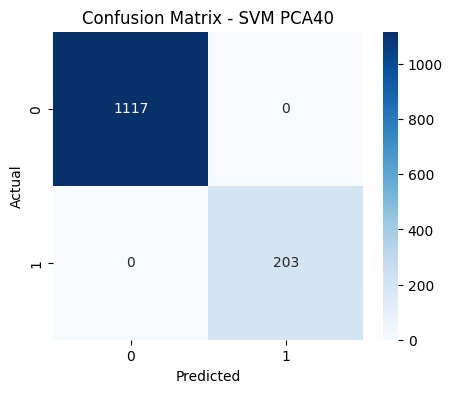

In [14]:
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns
import matplotlib.pyplot as plt

y_pred = svm_model.predict(X_test)

cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(5,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix - SVM PCA40")
plt.show()

In [16]:
report = classification_report(y_test, y_pred)
print("Classification Report:\n")
print(report)

Classification Report:

              precision    recall  f1-score   support

           0       1.00      1.00      1.00      1117
           1       1.00      1.00      1.00       203

    accuracy                           1.00      1320
   macro avg       1.00      1.00      1.00      1320
weighted avg       1.00      1.00      1.00      1320



In [17]:
svm_model.fit(X, y)

,C,1.0
,kernel,'rbf'
,degree,3
,gamma,'scale'
,coef0,0.0
,shrinking,True
,probability,False
,tol,0.001
,cache_size,200
,class_weight,None
,verbose,False


In [18]:
import joblib
joblib.dump(svm_model, "models/svm_pca40_final.joblib")

print("Finalni model sačuvan")

Finalni model sačuvan
